In [ ]:
import sys
sys.path.append("../src")

import GOenrichment as ge
import importlib

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv"
}


go_combined_by_subtype = {
}


for subtype, file in files.items():
    go_combined_by_subtype[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="combined"
    )
    
    



Proneural
Unique GO genes: 2123


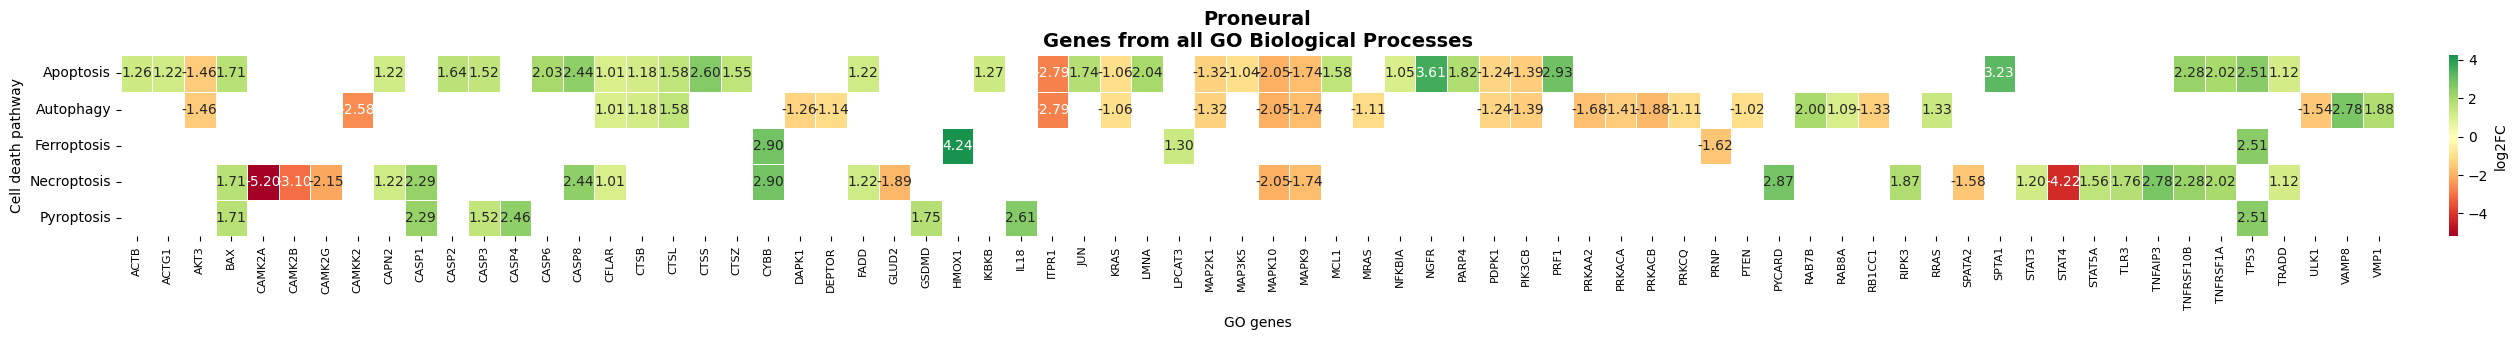


Classical
Unique GO genes: 2325


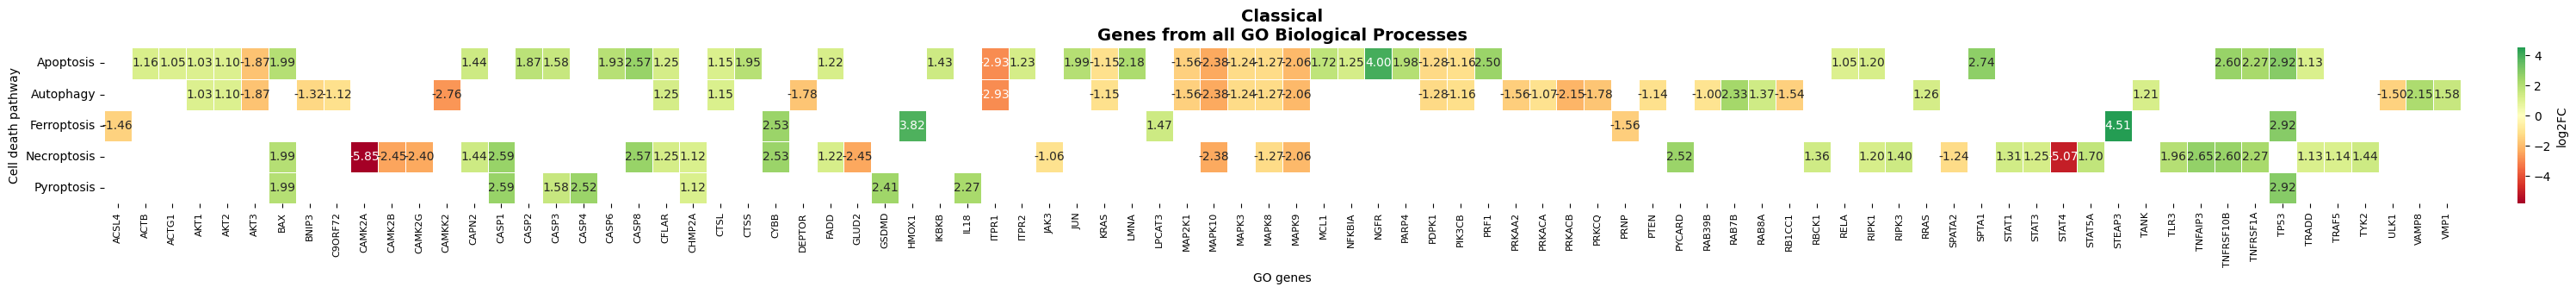


Mesenchymal
Unique GO genes: 2633


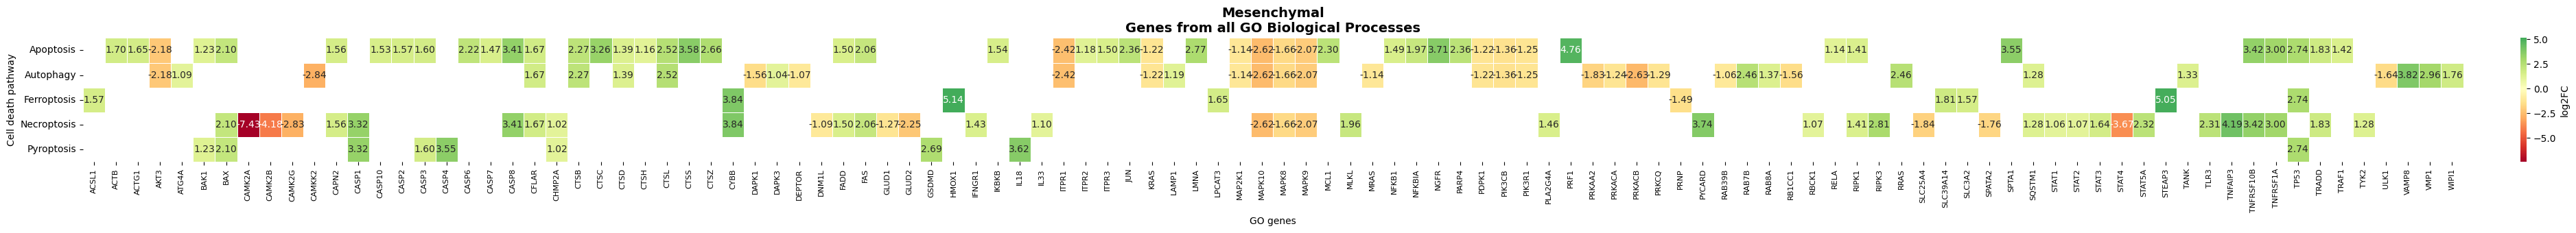

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PVAL = "pvalue_rna"
LOGFC = "log2FC_rna"

PATHWAY_DIR = "../data/processed/pathway_diff"

pathways = [
    "Apoptosis",
    "Autophagy",
    "Ferroptosis",
    "Necroptosis",
    "Pyroptosis"
]

for subtype in ["Proneural", "Classical", "Mesenchymal"]:

    print(f"\n{subtype}")

    ########################################################
    # Get ALL genes from ALL Biological Processes
    ########################################################

    bp = go_combined_by_subtype[subtype]["BP"]

    all_genes = set()

    for _, row in bp.iterrows():

        all_genes.update(
            g.upper()
            for g in row["Genes"].split(";")
        )

    genes = sorted(all_genes)

    print(f"Unique GO genes: {len(genes)}")

    ########################################################
    # Collect pathway information
    ########################################################

    folder = subtype.lower()

    records = []

    for pathway in pathways:

        file = os.path.join(
            PATHWAY_DIR,
            folder,
            f"{folder}_{pathway}_diff.csv"
        )

        df = pd.read_csv(
            file,
            index_col=0
        )

        df.index = df.index.astype(str).str.upper()

        sig = df[
            (df[PVAL] < ge.PVAL_THRESHOLD) &
            (abs(df[LOGFC]) > ge.LOGFC_THRESHOLD)
        ]

        overlap = sig.loc[
            sig.index.isin(genes)
        ]

        for gene in genes:

            if gene in overlap.index:

                records.append({
                    "Gene": gene,
                    "Pathway": pathway,
                    "log2FC": overlap.loc[
                        gene,
                        LOGFC
                    ]
                })

            else:

                records.append({
                    "Gene": gene,
                    "Pathway": pathway,
                    "log2FC": np.nan
                })

    ########################################################
    # Build heatmap matrix
    ########################################################

    heat = pd.DataFrame(records)

    heat = heat.pivot(
        index="Pathway",
        columns="Gene",
        values="log2FC"
    )

    heat = heat.reindex(pathways)

    # Remove genes with no significant value
    heat = heat.dropna(
        axis=1,
        how="all"
    )

    # If absolutely nothing overlaps,
    # show one empty column
    if heat.shape[1] == 0:

        heat["No overlap"] = np.nan

    ########################################################
    # Plot
    ########################################################

    plt.figure(
        figsize=(
            max(10, len(heat.columns) * 0.4),
            3.5
        )
    )

    sns.heatmap(
        heat,
        cmap="RdYlGn",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": "log2FC",
            "pad": 0.02
        }
    )

    plt.title(
        f"{subtype}\nGenes from all GO Biological Processes",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("GO genes")
    plt.ylabel("Cell death pathway")

    plt.xticks(
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        rotation=0
    )

    plt.tight_layout()

    plt.show()